<a href="https://colab.research.google.com/github/vituhaa/Healthy-Posture/blob/project/EfficientNetB0_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Работа с EfficientNetB0

EfficientNetB0 (Transfer Learning): This model uses a pre-trained EfficientNetB0 backbone with its weights frozen. A custom classification head—consisting of a Global Average Pooling layer, a Dense layer, and a Dropout layer—was added on top for the specific task of posture classification.

Optimizer: Adam

Loss Function: Binary Crossentropy

Epochs: 15

Data Augmentation: To improve generalization, the training data was augmented
with random horizontal flips, rotations, and zooms.

Both models were evaluated on an unseen test set of 27 images. While they achieved the same overall accuracy, their performance characteristics on a per-class basis were notably different.

Transfer learning tutorial - https://www.tensorflow.org/tutorials/images/transfer_learning

In [77]:
import tensorflow as tf
from matplotlib import pyplot as plt
import tensorflow.keras as keras
from tensorflow.keras.applications import EfficientNetB0
from keras import layers
import os

In [ ]:
from google.colab import drive
drive.mount('content/')

In [ ]:
categories = ['good', 'bad']

train_dir = '/content/content/MyDrive/датасет для курсовой работы, 3 курс/EfficientNetB0_dataset/train'
test_dir = '/content/content/MyDrive/датасет для курсовой работы, 3 курс/EfficientNetB0_dataset/test'

batch_size = 32
picture_size = 224

train_dataset = keras.utils.image_dataset_from_directory(train_dir, shuffle=True, batch_size=batch_size, image_size=(picture_size, picture_size))
test_dataset = keras.utils.image_dataset_from_directory(test_dir, shuffle=True, batch_size=batch_size, image_size=(picture_size, picture_size))

In [ ]:
inputs = layers.Input(shape=(picture_size, picture_size, 3))
base_model = EfficientNetB0(include_top=False, input_tensor=inputs, weights='imagenet')

base_model.trainable = False

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
print(outputs)
model = keras.Model(inputs, outputs)
optimizer = keras.optimizers.Adam(learning_rate=0.01)
loss = keras.losses.BinaryCrossentropy(from_logits=False)
model.compile(optimizer=optimizer, loss=loss, metrics=["accuracy"])

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
  print(labels)
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    if (labels[i] == 0):
      plt.title("bad")
    else:
      plt.title("good")
    plt.axis("off")

In [ ]:
# augmentation = tf.keras.Sequential([
#     tf.keras.layers.RandomFlip('horizontal'),
#     tf.keras.layers.RandomRotation(0.2)
# ])

# for image, _ in train_dataset.take(1):
#   first_image = image[0]
#   for i in range(9):
#     ax = plt.subplot(3, 3, i + 1)
#     aug_img = augmentation(tf.expand_dims(first_image, 0))
#     plt.imshow(aug_img[0] / 255)
#     plt.axis("off")

Epoch 1/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 196s 6s/step - accuracy: 0.8908 - loss: 0.2510 - val_accuracy: 0.9413 - val_loss: 0.1706
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 141s 4s/step - accuracy: 0.9550 - loss: 0.1172 - val_accuracy: 0.9470 - val_loss: 0.1573
Epoch 3/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 179s 5s/step - accuracy: 0.9703 - loss: 0.1004 - val_accuracy: 0.9583 - val_loss: 0.1435
Epoch 4/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 171s 4s/step - accuracy: 0.9751 - loss: 0.0716 - val_accuracy: 0.9659 - val_loss: 0.1231
Epoch 5/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 182s 6s/step - accuracy: 0.9789 - loss: 0.0619 - val_accuracy: 0.9508 - val_loss: 0.1538
Epoch 6/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 190s 6s/step - accuracy: 0.9875 - loss: 0.0607 - val_accuracy: 0.9432 - val_loss: 0.1621
Epoch 7/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 190s 6s/step - accuracy: 0.9856 - loss: 0.0517 - val_accuracy: 0.9451 - val_loss: 0.1634
Epoch 8/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 194s 6s/step - accuracy: 0.9904 - loss: 0.0515 - val_accuracy: 0.9489 - v

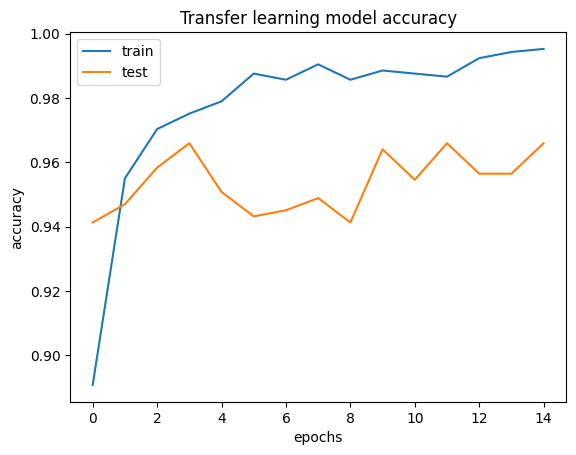

In [83]:
epochs = 15
graphics = model.fit(train_dataset, epochs=epochs, validation_data=test_dataset)

plt.plot(graphics.history["accuracy"])
plt.plot(graphics.history["val_accuracy"])
plt.title("Transfer learning model accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend(["train", "test"], loc="upper left")
plt.show()

In [ ]:
model.save('tl_EfficientNetB0.h5')

Custom CNN: A lightweight Convolutional Neural Network built from scratch. The architecture consists of three convolutional blocks with MaxPooling, followed by a dense classifier with a Dropout layer for regularization.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization

filers_size = (3, 3)

custom_cnn = Sequential([
    Conv2D(32, filers_size, activation='relu', padding='same', input_shape=(picture_size, picture_size, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, filers_size, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, filers_size, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Conv2D(256, filers_size, activation='relu', padding='same'),
    # BatchNormalization(),

    Flatten(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

optimizer = keras.optimizers.Adam(learning_rate=0.001)
loss = keras.losses.BinaryCrossentropy(from_logits=False)

custom_cnn.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=["accuracy"]
)

custom_cnn.fit(
    train_dataset,
    epochs=epochs,
    validation_data=test_dataset
)

In [ ]:
custom_cnn.save('custom_cnn.h5')